<a href="https://colab.research.google.com/github/runessaa/-Streltsov-Projects/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D0%B8_%D0%BB%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Практическая работа №5. Линейная и логистическая регрессия**



## **Линейная регрессия**



### **Задание №1. Прогнозирование продаж автомобилей**

- **Шаг 1**: Загрузите набор данных о продажах автомобилей, содержащий информацию о цене, возрасте, пробеге и других характеристиках.
  - **Совет №1**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте `pandas` для обнаружения пропусков (`df.isnull().sum()`) и выбросов (например, с помощью метода межквартильного размаха - `df.boxplot()`).
  - **Совет №2**: Для пропущенных значений используйте стратегию заполнения средними значениями или медианой, чтобы минимизировать влияние на распределение данных (`df.fillna()`).




- Ссылка на набор данных: https://www.kaggle.com/datasets/gagandeep16/car-sales

    Manufacturer              Model  Sales_in_thousands  4-year_resale_value  \
0  Acura          Integra                        16.919               16.360   
1  Acura          TL                             39.384               19.875   
2  Acura          CL                             14.114               18.225   
3  Acura          RL                              8.588               29.725   
4  Audi           A4                             20.397               22.255   

  Vehicle_type  Price_in_thousands  Engine_size  Horsepower  Wheelbase  Width  \
0    Passenger              21.500          1.8       140.0      101.2   67.3   
1    Passenger              28.400          3.2       225.0      108.1   70.3   
2    Passenger              22.799          3.2       225.0      106.9   70.6   
3    Passenger              42.000          3.5       210.0      114.6   71.4   
4    Passenger              23.990          1.8       150.0      102.6   68.2   

   Length  Curb_weight  Fuel_cap

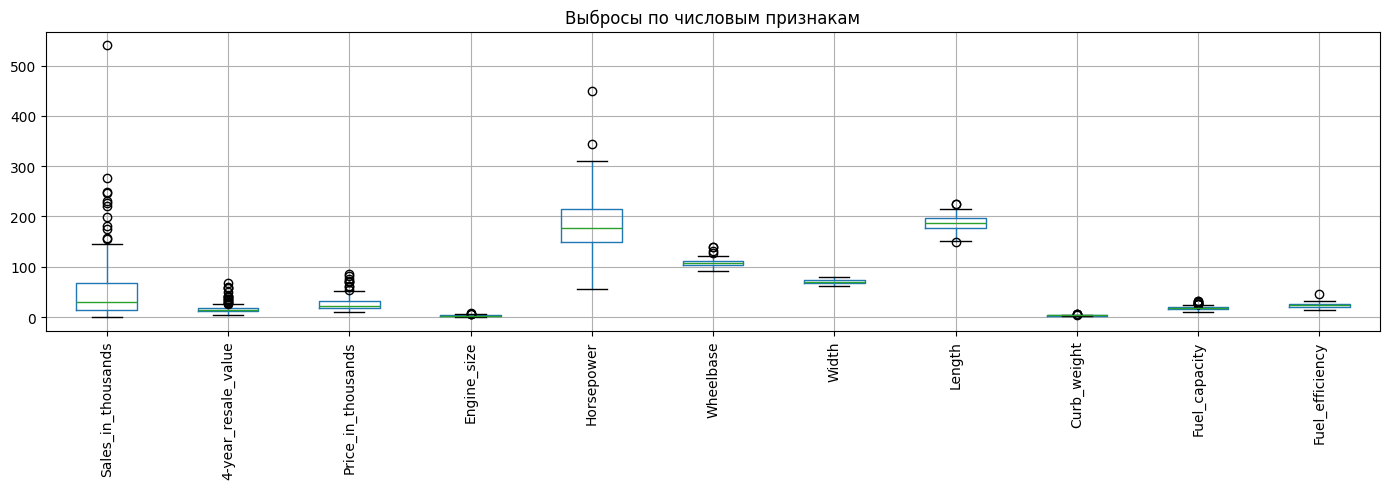

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url1 = 'https://raw.githubusercontent.com/chandanverma07/DataSets/master/Car_sales.csv'
df1 = pd.read_csv(url1)

df1.columns = df1.columns.str.strip().str.replace(' ', '_')
df1 = df1.replace('.', pd.NA)

text_cols1 = ['Manufacturer', 'Model', 'Vehicle_type', 'Latest_Launch']
for col in df1.columns:
  if col not in text_cols1:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

num_cols1 = df1.select_dtypes(include='number').columns
df1[num_cols1] = df1[num_cols1].fillna(df1[num_cols1].median())

print(df1.head())
print()
print(df1.isnull().sum())

df1.boxplot(figsize=(14, 5), rot=90)
plt.title('Выбросы по числовым признакам')
plt.tight_layout()
plt.show()

- **Шаг 2**: Проведите предварительный анализ данных:
  - Постройте гистограммы для каждого числового признака, чтобы понять их распределение.
  - Постройте диаграммы рассеяния для выявления зависимостей между признаками и целевой переменной (ценой).
  - **Совет**: Используйте корреляционную матрицу для выявления сильных линейных зависимостей между признаками.

Размер: (157, 15)

Manufacturer            object
Model                   object
Sales_in_thousands     float64
4-year_resale_value    float64
Vehicle_type            object
Price_in_thousands     float64
Engine_size            float64
Horsepower             float64
Wheelbase              float64
Width                  float64
Length                 float64
Curb_weight            float64
Fuel_capacity          float64
Fuel_efficiency        float64
Latest_Launch           object
dtype: object

         Manufacturer              Model  Sales_in_thousands  \
count             157                157          157.000000   
unique             30                156                 NaN   
top     Ford           Neon                              NaN   
freq               11                  2                 NaN   
mean              NaN                NaN           52.998076   
std               NaN                NaN           68.029422   
min               NaN                NaN            0

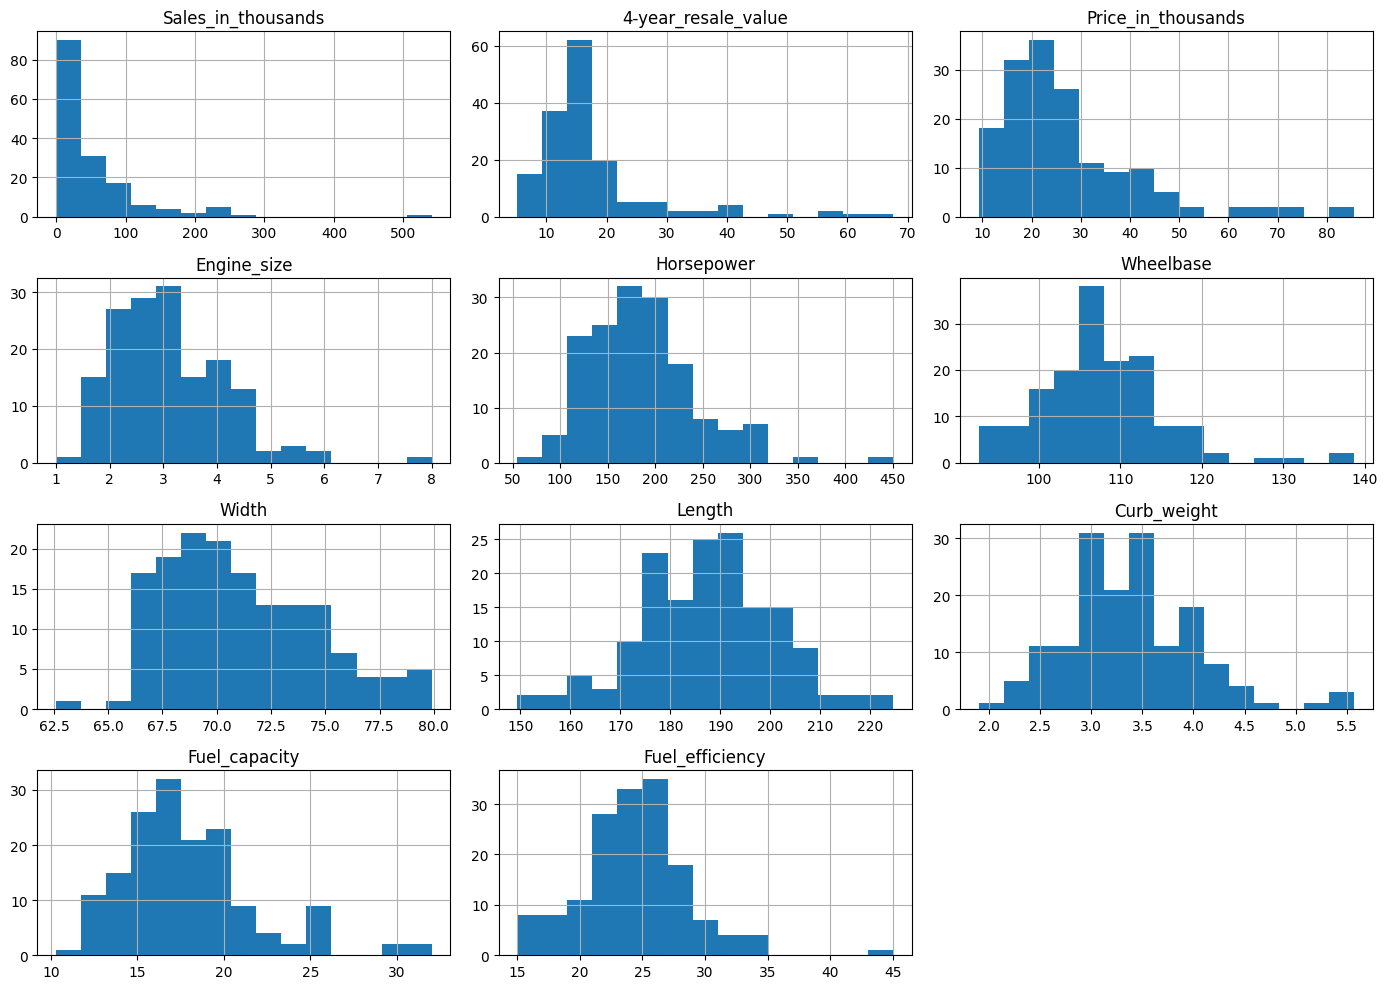

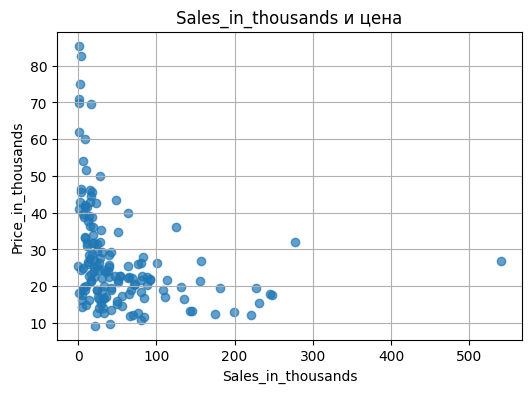

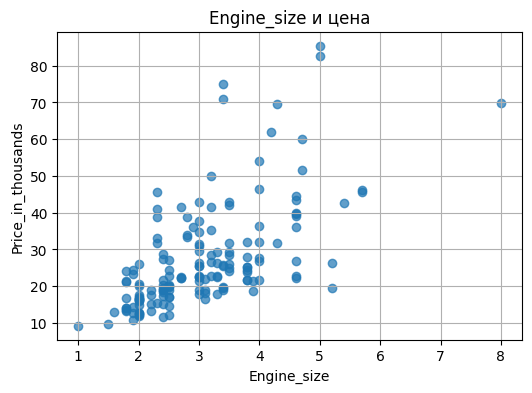

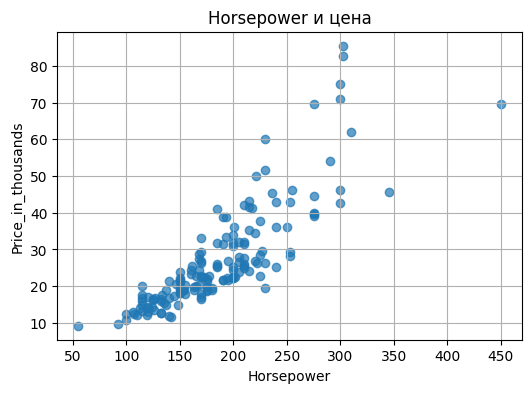

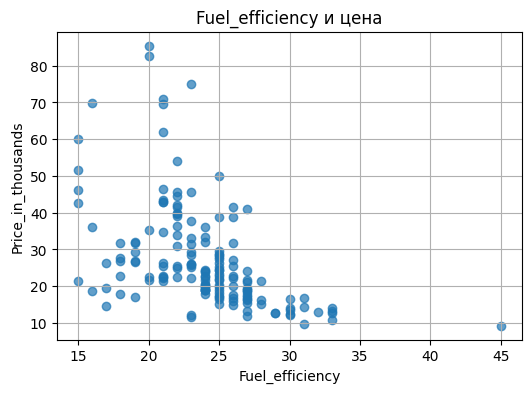

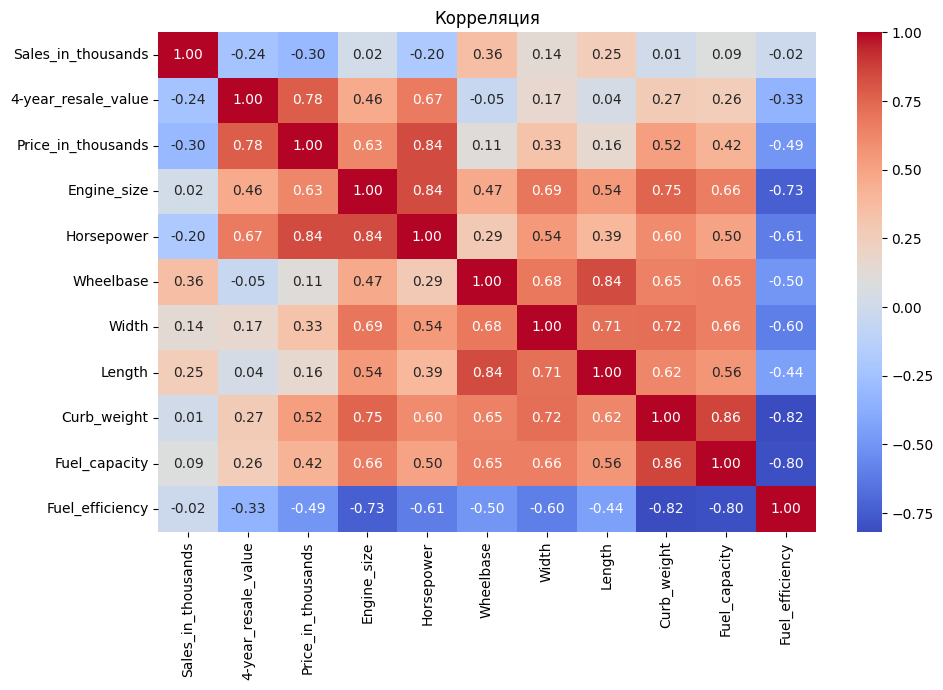

In [4]:
print('Размер:', df1.shape)
print()
print(df1.dtypes)
print()
print(df1.describe(include='all'))

num_cols1 = df1.select_dtypes(include='number').columns
df1[num_cols1].hist(figsize=(14, 10), bins=15)
plt.tight_layout()
plt.show()

for col in ['Sales_in_thousands', 'Engine_size', 'Horsepower', 'Fuel_efficiency']:
  if col in df1.columns:
    plt.figure(figsize=(6, 4))
    plt.scatter(df1[col], df1['Price_in_thousands'], alpha=0.7)
    plt.xlabel(col)
    plt.ylabel('Price_in_thousands')
    plt.title(f'{col} и цена')
    plt.grid(True)
    plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df1[num_cols1].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция')
plt.tight_layout()
plt.show()

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки (например, 70% на обучение и 30% на тестирование) с помощью `train_test_split` из `sklearn.model_selection`.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target1 = 'Price_in_thousands'

obj_cols1 = df1.select_dtypes(include='object').columns
for col in obj_cols1:
  df1[col] = df1[col].fillna(df1[col].mode()[0])

df1 = df1.dropna(subset=[target1])

X1 = df1.drop(columns=[target1, 'Model', 'Latest_Launch'])
y1 = df1[target1]

X1 = pd.get_dummies(X1, drop_first=True)

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=42)

scaler1 = StandardScaler()
X_train1_scaled = scaler1.fit_transform(X_train1)
X_test1_scaled = scaler1.transform(X_test1)

print(X_train1.shape, X_test1.shape)

(109, 40) (48, 40)


- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **ElasticNet** (комбинация L1 и L2) с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV`.
  - **Совет**: Используйте `np.logspace(-4, 4, 50)` для генерации сетки значений `alpha`.



In [8]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

models1 = {}
best_params1 = {}

lin1 = LinearRegression()
lin1.fit(X_train1_scaled, y_train1)
models1['LinearRegression'] = lin1
best_params1['LinearRegression'] = 'без подбора'

ridge_search1 = GridSearchCV(
    Ridge(),
    param_grid={'alpha': np.logspace(-4, 4, 20)},
    cv=5,
    scoring='neg_mean_squared_error'
    )
ridge_search1.fit(X_train1_scaled, y_train1)
models1['Ridge'] = ridge_search1.best_estimator_
best_params1['Ridge'] = ridge_search1.best_params_

lasso_search1 = RandomizedSearchCV(
    Lasso(max_iter=10000),
    param_distributions={'alpha': np.logspace(-4, 4, 50)},
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42
    )
lasso_search1.fit(X_train1_scaled, y_train1)
models1['Lasso'] = lasso_search1.best_estimator_
best_params1['Lasso'] = lasso_search1.best_params_

elastic_search1 = GridSearchCV(
    ElasticNet(max_iter=10000),
    param_grid={
        'alpha': np.logspace(-4, 2, 10),
        'l1_ratio': [0.2, 0.4, 0.6, 0.8]
        },
    cv=5,
    scoring='neg_mean_squared_error'
    )
elastic_search1.fit(X_train1_scaled, y_train1)
models1['ElasticNet'] = elastic_search1.best_estimator_
best_params1['ElasticNet'] = elastic_search1.best_params_

- **Шаг 5**: Оцените качество всех моделей с использованием метрик MSE, RMSE, MAE и R².
  - Выведите значения метрик для каждой модели и интерпретируйте их.


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results1 = []
preds1 = {}

for name, model in models1.items():
  pred = model.predict(X_test1_scaled)
  preds1[name] = pred
  mse = mean_squared_error(y_test1, pred)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test1, pred)
  r2 = r2_score(y_test1, pred)
  results1.append([name, mse, rmse, mae, r2])
results_df1 = pd.DataFrame(results1, columns=['Model', 'MSE', 'RMSE', 'MAE', 'R2'])
print(results_df1)

              Model        MSE      RMSE       MAE        R2
0  LinearRegression  82.046755  9.057966  6.147180  0.713794
1             Ridge  52.581882  7.251337  4.549690  0.816577
2             Lasso  54.509372  7.383046  4.707493  0.809854
3        ElasticNet  51.943436  7.207179  4.569243  0.818804


- **Шаг 6**: Визуализируйте результаты:
  - Постройте график зависимости предсказанных цен от фактических для каждой модели.



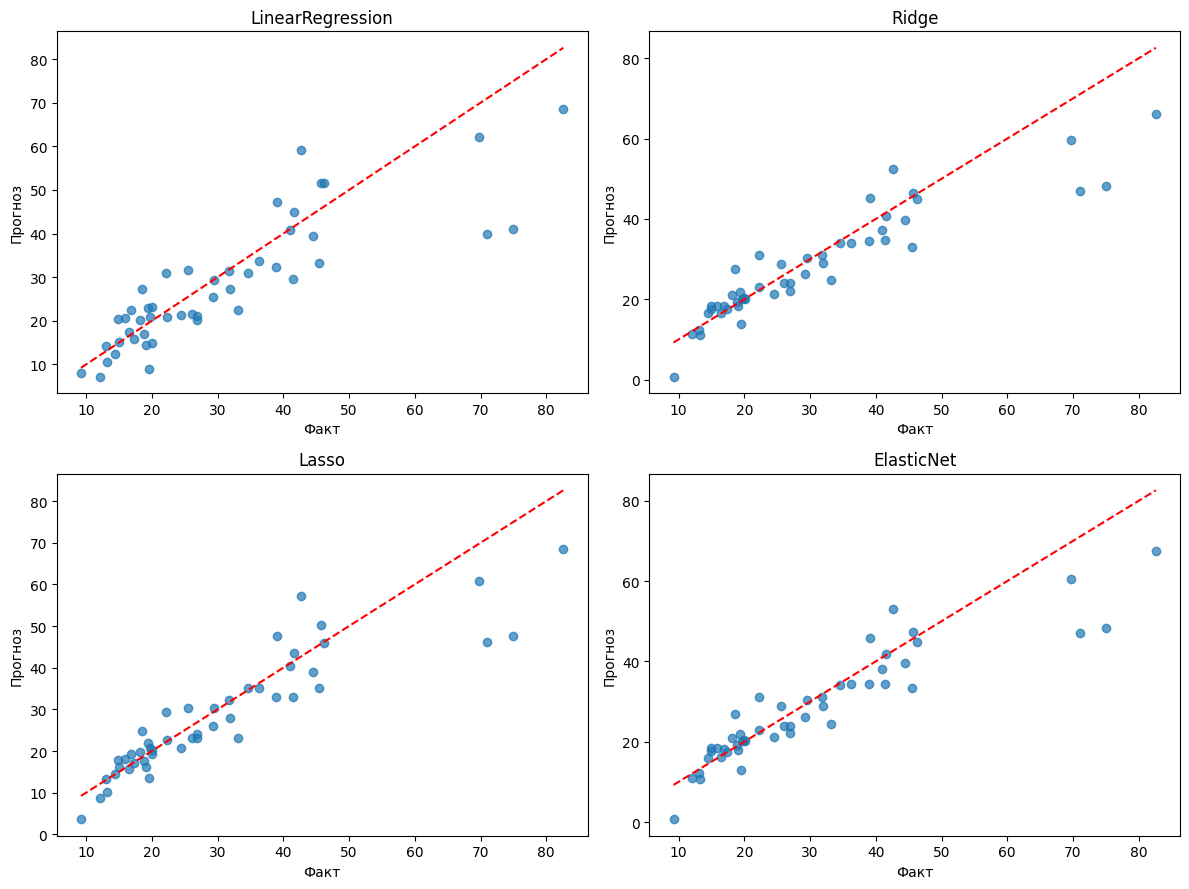

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, (name, pred) in zip(axes, preds1.items()):
  ax.scatter(y_test1, pred, alpha=0.7)
  ax.plot([y_test1.min(), y_test1.max()], [y_test1.min(), y_test1.max()], 'r--')
  ax.set_title(name)
  ax.set_xlabel('Факт')
  ax.set_ylabel('Прогноз')

plt.tight_layout()
plt.show()



- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.


In [11]:
results_df1 = results_df1.sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df1)

best_name1 = results_df1.loc[0, 'Model']
print()
print('Лучшая модель:', best_name1)
print('Параметры:', best_params1[best_name1])

              Model        MSE      RMSE       MAE        R2
0        ElasticNet  51.943436  7.207179  4.569243  0.818804
1             Ridge  52.581882  7.251337  4.549690  0.816577
2             Lasso  54.509372  7.383046  4.707493  0.809854
3  LinearRegression  82.046755  9.057966  6.147180  0.713794

Лучшая модель: ElasticNet
Параметры: {'alpha': np.float64(0.21544346900318823), 'l1_ratio': 0.2}


---



### **Задание №2. Влияние погодных условий на урожайность**




- **Шаг 1**: Загрузите набор данных о погодных условиях и урожайности сельскохозяйственных культур.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture


   Year Country         Region  Crop_Type  Average_Temperature_C  \
0  2001   India    West Bengal       Corn                   1.55   
1  2024   China          North       Corn                   3.23   
2  2001  France  Ile-de-France      Wheat                  21.11   
3  2001  Canada       Prairies     Coffee                  27.85   
4  1998   India     Tamil Nadu  Sugarcane                   2.19   

   Total_Precipitation_mm  CO2_Emissions_MT  Crop_Yield_MT_per_HA  \
0                  447.06             15.22                 1.737   
1                 2913.57             29.82                 1.737   
2                 1301.74             25.75                 1.719   
3                 1154.36             13.91                 3.890   
4                 1627.48             11.81                 1.080   

   Extreme_Weather_Events  Irrigation_Access_%  Pesticide_Use_KG_per_HA  \
0                       8                14.54                    10.08   
1                       8 

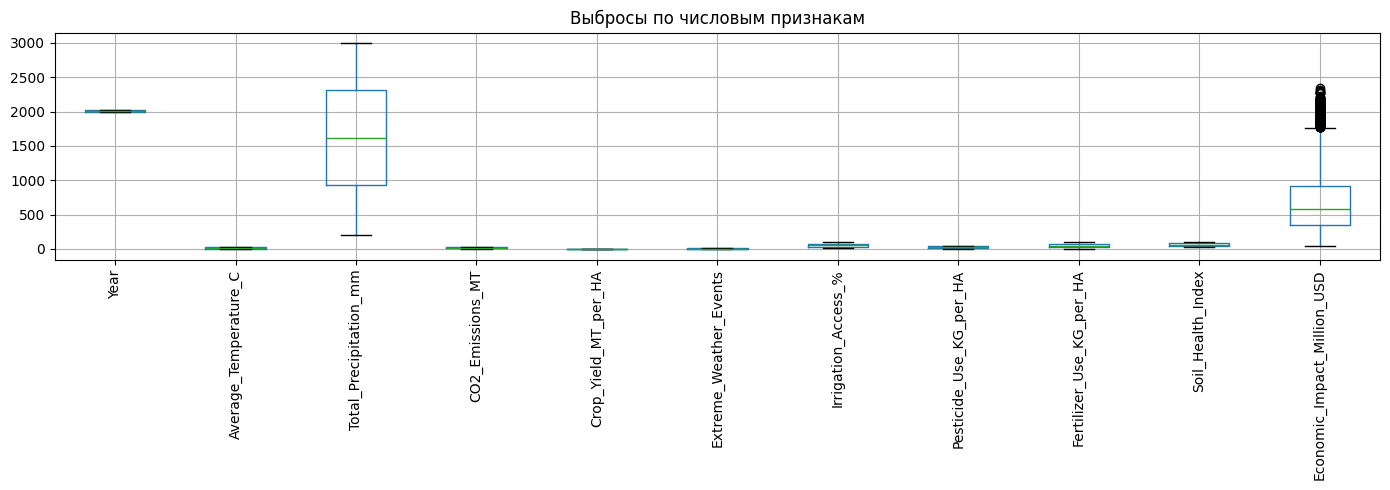

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://gist.githubusercontent.com/juanu/2122c882d93d0cff000b9a10389bff6d/raw/18e8be2c3a02561d560a64f7207696ba57bd6e3f/climate_change_impact_on_agriculture_2024.csv'
df2 = pd.read_csv(url)

print(df2.head())
print()
print('Размер:', df2.shape)
print()
print(df2.isnull().sum())

num_cols2 = df2.select_dtypes(include='number').columns
obj_cols2 = df2.select_dtypes(include='object').columns

df2[num_cols2] = df2[num_cols2].fillna(df2[num_cols2].median())

for col in obj_cols2:
  df2[col] = df2[col].fillna(df2[col].mode()[0])

plt.figure(figsize=(14, 5))
df2[num_cols2].boxplot(rot=90)
plt.title('Выбросы по числовым признакам')
plt.tight_layout()
plt.show()




- **Шаг 2**: Выполните анализ данных:
  - Постройте корреляционную матрицу для выявления зависимостей между признаками.
  - Постройте диаграммы рассеяния для ключевых признаков.
  - **Совет**: Удалите или преобразуйте признаки с низкой корреляцией с целевой переменной, чтобы улучшить модель.



Year                             int64
Country                         object
Region                          object
Crop_Type                       object
Average_Temperature_C          float64
Total_Precipitation_mm         float64
CO2_Emissions_MT               float64
Crop_Yield_MT_per_HA           float64
Extreme_Weather_Events           int64
Irrigation_Access_%            float64
Pesticide_Use_KG_per_HA        float64
Fertilizer_Use_KG_per_HA       float64
Soil_Health_Index              float64
Adaptation_Strategies           object
Economic_Impact_Million_USD    float64
dtype: object

                Year    Country Region Crop_Type  Average_Temperature_C  \
count   10000.000000      10000  10000     10000           10000.000000   
unique           NaN         10     34        10                    NaN   
top              NaN  Australia  South     Wheat                    NaN   
freq             NaN       1032    754      1047                    NaN   
mean     2007.088700     

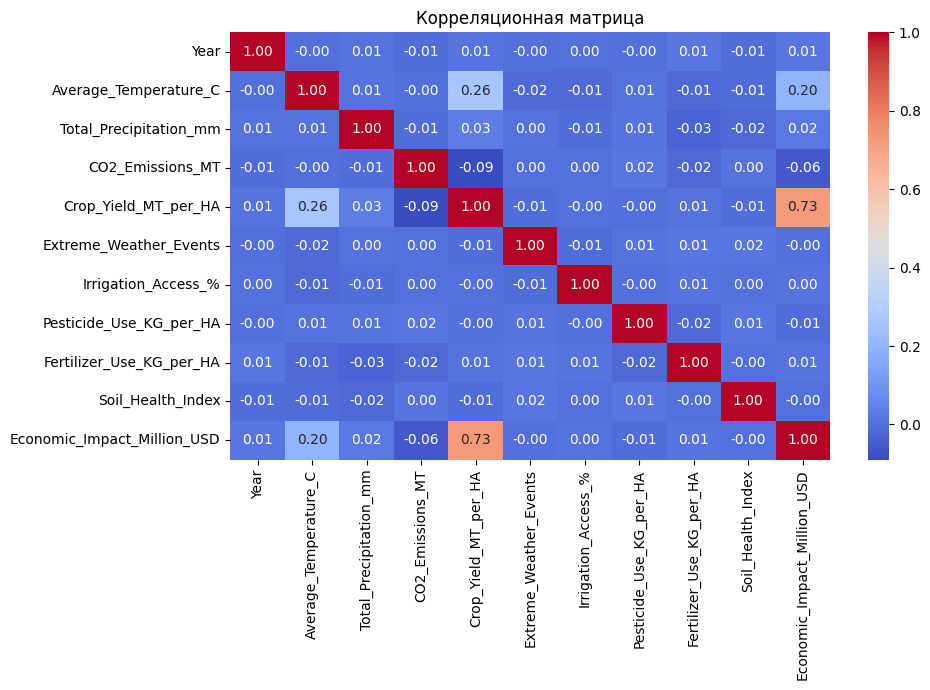

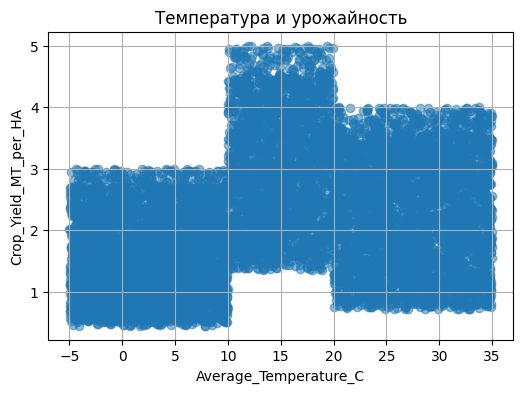

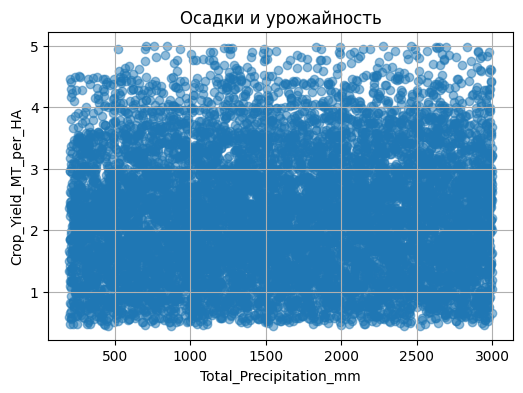

In [17]:
target2 = 'Crop_Yield_MT_per_HA'

print(df2.dtypes)
print()
print(df2.describe(include='all'))

corr2 = df2[num_cols2].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr2, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df2['Average_Temperature_C'], df2[target2], alpha=0.5)
plt.xlabel('Average_Temperature_C')
plt.ylabel('Crop_Yield_MT_per_HA')
plt.title('Температура и урожайность')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df2['Total_Precipitation_mm'], df2[target2], alpha=0.5)
plt.xlabel('Total_Precipitation_mm')
plt.ylabel('Crop_Yield_MT_per_HA')
plt.title('Осадки и урожайность')
plt.grid(True)
plt.show()

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X2 = df2.drop(columns=['Crop_Yield_MT_per_HA'])
y2 = df2['Crop_Yield_MT_per_HA']

X2 = pd.get_dummies(X2, drop_first=True)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=42)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

print(X_train2.shape, X_test2.shape)

(7000, 65) (3000, 65)




- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации для оценки влияния температуры и уровня осадков на урожайность:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **ElasticNet** с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .

In [20]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

models2 = {}
best_params2 = {}

lin2 = LinearRegression()
lin2.fit(X_train2_scaled, y_train2)
models2['LinearRegression'] = lin2
best_params2['LinearRegression'] = 'без подбора'

ridge_search2 = RandomizedSearchCV(
    Ridge(),
    param_distributions={'alpha': np.linspace(0.01, 20, 100)},
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42
)
ridge_search2.fit(X_train2_scaled, y_train2)
models2['Ridge'] = ridge_search2.best_estimator_
best_params2['Ridge'] = ridge_search2.best_params_

lasso_search2 = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid={'alpha': [0.001, 0.01, 0.1, 1]},
    cv=5,
    scoring='neg_mean_squared_error'
)
lasso_search2.fit(X_train2_scaled, y_train2)
models2['Lasso'] = lasso_search2.best_estimator_
best_params2['Lasso'] = lasso_search2.best_params_

elastic_search2 = GridSearchCV(
    ElasticNet(max_iter=10000),
    param_grid={
        'alpha': [0.001, 0.01, 0.1, 1],
        'l1_ratio': [0.2, 0.5, 0.8]
    },
    cv=5,
    scoring='neg_mean_squared_error'
)
elastic_search2.fit(X_train2_scaled, y_train2)
models2['ElasticNet'] = elastic_search2.best_estimator_
best_params2['ElasticNet'] = elastic_search2.best_params_

- **Шаг 5**: Проведите оценку точности всех моделей.
  - Выведите значения метрик MSE, RMSE, MAE и R² для каждой модели и интерпретируйте их.

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results2 = []
preds2 = {}

for name, model in models2.items():
  pred = model.predict(X_test2_scaled)
  preds2[name] = pred
  mse = mean_squared_error(y_test2, pred)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test2, pred)
  r2 = r2_score(y_test2, pred)
  results2.append([name, mse, rmse, mae, r2])

results_df2 = pd.DataFrame(results2, columns=['Model', 'MSE', 'RMSE', 'MAE', 'R2'])
print(results_df2)

              Model       MSE      RMSE       MAE        R2
0  LinearRegression  0.454914  0.674473  0.542454  0.553323
1             Ridge  0.454936  0.674489  0.542408  0.553301
2             Lasso  0.451111  0.671648  0.540936  0.557057
3        ElasticNet  0.451643  0.672044  0.541120  0.556535




- **Шаг 6**: Визуализируйте данные и результаты моделей:
  - Постройте графики зависимости предсказанных значений от фактических для каждой модели.

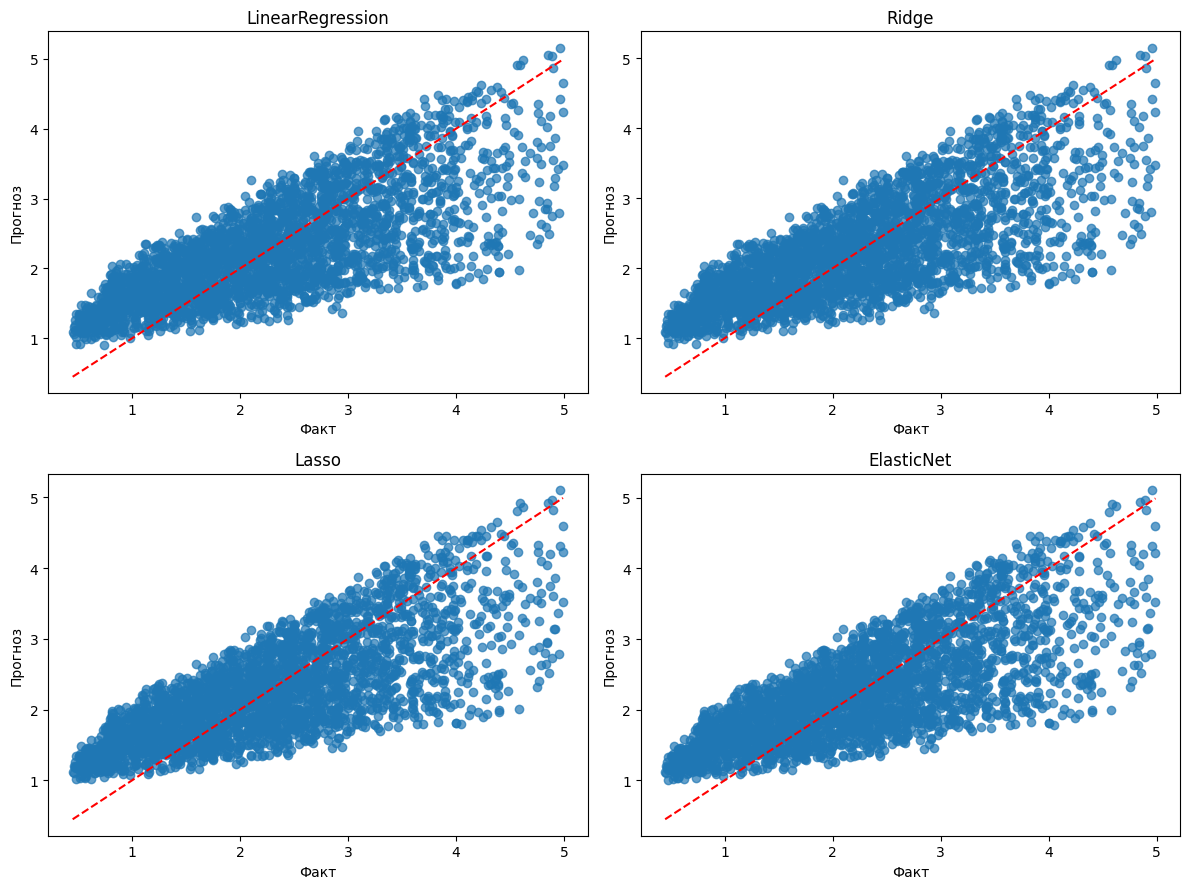

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, (name, pred) in zip(axes, preds2.items()):
  ax.scatter(y_test2, pred, alpha=0.7)
  ax.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], 'r--')
  ax.set_title(name)
  ax.set_xlabel('Факт')
  ax.set_ylabel('Прогноз')

plt.tight_layout()
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.

In [23]:
results_df2 = results_df2.sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df2)

best_name2 = results_df2.loc[0, 'Model']
print()
print('Лучшая модель:', best_name2)
print('Параметры:', best_params2[best_name2])

              Model       MSE      RMSE       MAE        R2
0             Lasso  0.451111  0.671648  0.540936  0.557057
1        ElasticNet  0.451643  0.672044  0.541120  0.556535
2  LinearRegression  0.454914  0.674473  0.542454  0.553323
3             Ridge  0.454936  0.674489  0.542408  0.553301

Лучшая модель: Lasso
Параметры: {'alpha': 0.01}


- **Шаг 8: Проанализируйте влияние признаков на урожайность**

  - На основе лучшей модели проведите анализ важности признаков:

    - Извлеките коэффициенты (`coef_`) лучшей модели и сопоставьте их с названиями признаков.
    - Визуализируйте важность признаков с помощью горизонтальной столбчатой диаграммы.
    - Проинтерпретируйте результаты: определите, какие погодные факторы (температура, осадки, CO₂ и др.) оказывают наибольшее положительное и отрицательное влияние на урожайность.
    - **Совет**: Для модели Lasso обратите внимание на признаки с нулевыми коэффициентами — они были исключены как незначимые.
    - **Совет**: Если данные были стандартизированы (`StandardScaler`), коэффициенты можно напрямую сравнивать по абсолютной величине для оценки относительной важности.



Самые сильные признаки:
                                  feature      coef
9             Economic_Impact_Million_USD  0.679307
1                   Average_Temperature_C  0.125162
3                        CO2_Emissions_MT -0.037478
30                       Region_Northwest  0.009976
49                            Region_West  0.009013
63  Adaptation_Strategies_Organic Farming  0.006720
45                       Region_Southeast  0.005453
2                  Total_Precipitation_mm  0.005088
54                       Crop_Type_Cotton -0.004814
35                       Region_Patagonia -0.004219

Положительные коэффициенты:
                                  feature      coef
9             Economic_Impact_Million_USD  0.679307
1                   Average_Temperature_C  0.125162
30                       Region_Northwest  0.009976
49                            Region_West  0.009013
63  Adaptation_Strategies_Organic Farming  0.006720

Отрицательные коэффициенты:
               feature      coef
3

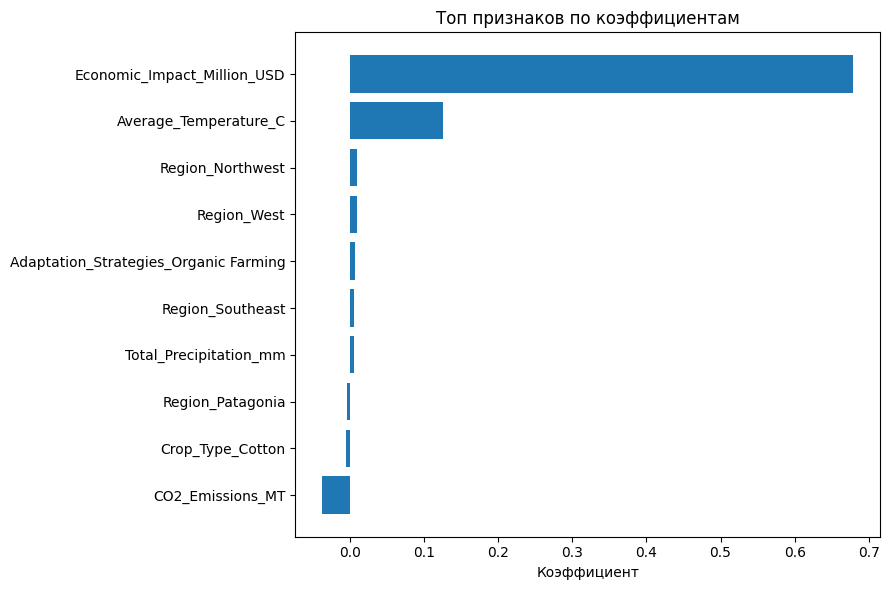

In [25]:
best_model2 = models2[best_name2]

coef_df2 = pd.DataFrame({
    'feature': X2.columns,
    'coef': best_model2.coef_
    })

coef_df2['abs_coef'] = coef_df2['coef'].abs()
coef_df2 = coef_df2.sort_values('abs_coef', ascending=False)

print('Самые сильные признаки:')
print(coef_df2[['feature', 'coef']].head(10))
print()
print('Положительные коэффициенты:')
print(coef_df2[coef_df2['coef'] > 0][['feature', 'coef']].head(5))
print()
print('Отрицательные коэффициенты:')
print(coef_df2[coef_df2['coef'] < 0][['feature', 'coef']].head(5))

top10 = coef_df2.head(10).sort_values('coef')

plt.figure(figsize=(9, 6))
plt.barh(top10['feature'], top10['coef'])
plt.title('Топ признаков по коэффициентам')
plt.xlabel('Коэффициент')
plt.tight_layout()
plt.show()

#### **Интерпретация результатов (пример формулировки для отчёта):**


По таблице выше видно, какие признаки сильнее всего влияют на урожайность. Плюс в коэффициенте значит рост прогноза, минус — снижение. Для вывода можно брать самые большие по модулю коэффициенты.

- самые важные признаки смотрим в начале таблицы;
- положительные коэффициенты повышают прогноз урожайности;
- отрицательные коэффициенты понижают прогноз урожайности.

---



## **Логистическая регрессия**



### **Задание №3. Классификация клиентов банка**

- **Шаг 1**: Загрузите набор данных о клиентах банка, включающий данные о возрасте, доходе, кредитной истории и других характеристиках.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.



- Ссылка на набор данных: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data

   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan 

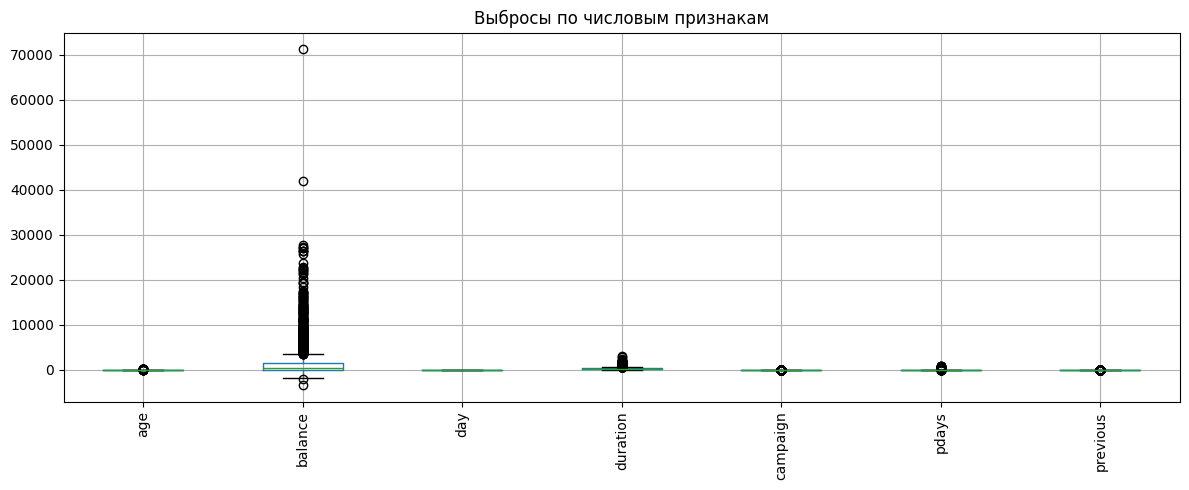

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url3 = 'https://raw.githubusercontent.com/Bahaakhalled/Bank-Marketing-Classification/main/bank.csv'
df3 = pd.read_csv(url3, sep=';')

num_cols3 = df3.select_dtypes(include='number').columns
df3[num_cols3] = df3[num_cols3].fillna(df3[num_cols3].median())

obj_cols3 = df3.select_dtypes(include='object').columns
for col in obj_cols3:
  df3[col] = df3[col].fillna(df3[col].mode()[0])

print(df3.head())
print()
print(df3.isnull().sum())

df3[num_cols3].boxplot(figsize=(12, 5), rot=90)
plt.title('Выбросы по числовым признакам')
plt.tight_layout()
plt.show()

- **Шаг 2**: Проведите анализ данных и предобработку:
  - Закодируйте категориальные переменные с помощью `OneHotEncoder` или `pd.get_dummies`.
  - Нормализуйте числовые признаки с помощью `StandardScaler` для улучшения обучения модели.
  - **Совет**: Убедитесь, что все признаки имеют одинаковый масштаб, чтобы избежать доминирования одного признака над другими.

In [27]:
print('Размер:', df3.shape)
print()
print(df3.dtypes)
print()
print(df3['y'].value_counts())

df3['y'] = df3['y'].map({'no': 0, 'yes': 1})

X3 = df3.drop(columns=['y'])
X3 = pd.get_dummies(X3, drop_first=True)
y3 = df3['y']

Размер: (4521, 17)

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

y
no     4000
yes     521
Name: count, dtype: int64


- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.3, random_state=42, stratify=y3)

scaler3 = StandardScaler()
X_train3_scaled = scaler3.fit_transform(X_train3)
X_test3_scaled = scaler3.transform(X_test3)

print(X_train3.shape, X_test3.shape)

(3164, 42) (1357, 42)


- **Шаг 4**: Постройте и обучите модели логистической регрессии с различными типами регуляризации для предсказания вероятности открытия депозитного счета клиентом:
  - Обучите модель `LogisticRegression` с **L2-регуляризацией** (`penalty='l2'`) и подбором гиперпараметра `C` с помощью `GridSearchCV`.
  - Обучите модель `LogisticRegression` с **L1-регуляризацией** (`penalty='l1'`, `solver='saga'`) и подбором гиперпараметра `C` с помощью `RandomizedSearchCV`.
  - Обучите модель `LogisticRegression` с **ElasticNet-регуляризацией** (`penalty='elasticnet'`, `solver='saga'`) и подбором гиперпараметров `C` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .
  - **Совет**: Для L1 и ElasticNet используйте `solver='saga'`, так как он поддерживает оба типа регуляризации.


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

models3 = {}
best_params3 = {}

l2_search3 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='lbfgs', max_iter=5000),
    param_grid={'C': np.logspace(-2, 2, 10)},
    cv=5,
    scoring='roc_auc'
    )
l2_search3.fit(X_train3_scaled, y_train3)
models3['L2'] = l2_search3.best_estimator_
best_params3['L2'] = l2_search3.best_params_

l1_search3 = RandomizedSearchCV(
    LogisticRegression(penalty='l1', solver='saga', max_iter=5000),
    param_distributions={'C': np.logspace(-2, 2, 30)},
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    random_state=42
    )
l1_search3.fit(X_train3_scaled, y_train3)
models3['L1'] = l1_search3.best_estimator_
best_params3['L1'] = l1_search3.best_params_

elastic_search3 = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000),
    param_grid={
        'C': np.logspace(-2, 2, 6),
        'l1_ratio': [0.2, 0.4, 0.6, 0.8]
    },
    cv=5,
    scoring='roc_auc'
    )
elastic_search3.fit(X_train3_scaled, y_train3)
models3['ElasticNet'] = elastic_search3.best_estimator_
best_params3['ElasticNet'] = elastic_search3.best_params_


- **Шаг 5**: Оцените качество всех моделей с использованием метрик точности (Accuracy), полноты (Recall), точности (Precision) и F1-меры.
  - Выведите значения метрик для каждой модели и интерпретируйте их. Обратите внимание на баланс между точностью и полнотой.
  - Постройте матрицу ошибок для каждой модели с помощью `confusion_matrix` и визуализируйте их с помощью `seaborn.heatmap`.

        Model  Accuracy  Precision    Recall        F1       AUC
0          L2  0.891673   0.591837  0.185897  0.282927  0.881616
1          L1  0.897568   0.619718  0.282051  0.387665  0.889067
2  ElasticNet  0.890199   0.585366  0.153846  0.243655  0.883313


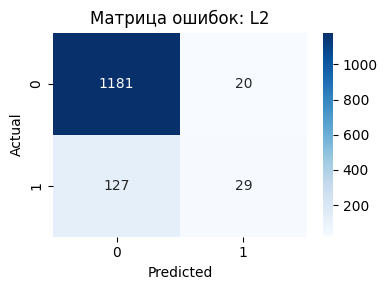

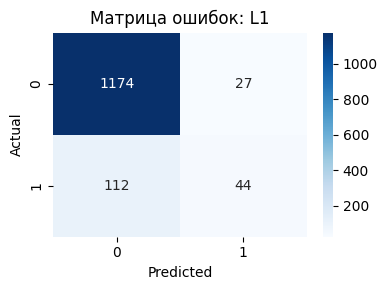

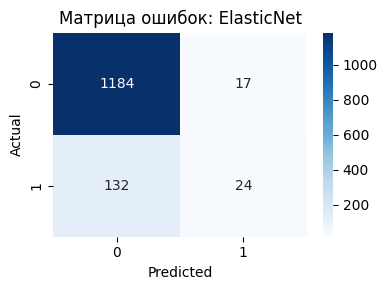

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

results3 = []
roc_curves3 = {}
conf_matrices3 = {}

for name, model in models3.items():
  pred = model.predict(X_test3_scaled)
  proba = model.predict_proba(X_test3_scaled)[:, 1]
  acc = accuracy_score(y_test3, pred)
  prec = precision_score(y_test3, pred)
  rec = recall_score(y_test3, pred)
  f1 = f1_score(y_test3, pred)
  auc = roc_auc_score(y_test3, proba)
  results3.append([name, acc, prec, rec, f1, auc])
  conf_matrices3[name] = confusion_matrix(y_test3, pred)
  fpr, tpr, _ = roc_curve(y_test3, proba)
  roc_curves3[name] = [fpr, tpr, auc]
results_df3 = pd.DataFrame(
    results3,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
    )
print(results_df3)

for name, matrix in conf_matrices3.items():
  plt.figure(figsize=(4, 3))
  sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
  plt.title(f'Матрица ошибок: {name}')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.tight_layout()
  plt.show()

- **Шаг 6**: Визуализируйте ROC-кривые для всех моделей и вычислите AUC для оценки.
  - Используйте `roc_curve` и `auc` из `sklearn.metrics` для построения и расчёта.
  - Постройте все ROC-кривые на одном графике для наглядного сравнения.



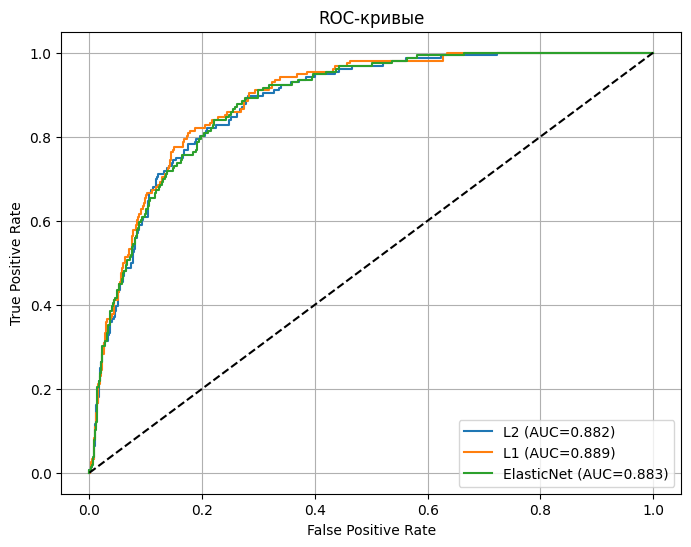

In [34]:
plt.figure(figsize=(8, 6))

for name, values in roc_curves3.items():
  fpr, tpr, auc = values
  plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid(True)
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (Accuracy, Precision, Recall, F1, AUC)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, оптимальные гиперпараметры и матрицу ошибок.

        Model  Accuracy  Precision    Recall        F1       AUC
0          L1  0.897568   0.619718  0.282051  0.387665  0.889067
1  ElasticNet  0.890199   0.585366  0.153846  0.243655  0.883313
2          L2  0.891673   0.591837  0.185897  0.282927  0.881616

Лучшая модель: L1
Параметры: {'C': np.float64(0.12689610031679222)}


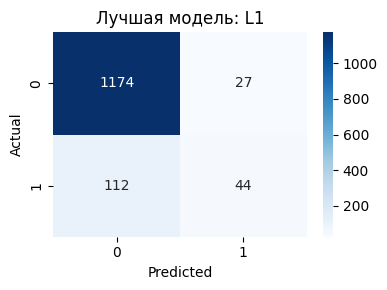

In [35]:
results_df3 = results_df3.sort_values('AUC', ascending=False).reset_index(drop=True)
print(results_df3)

best_name3 = results_df3.loc[0, 'Model']
print()
print('Лучшая модель:', best_name3)
print('Параметры:', best_params3[best_name3])

plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrices3[best_name3], annot=True, fmt='d', cmap='Blues')
plt.title(f'Лучшая модель: {best_name3}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()